# ML Project - Social media impact on students academics

## Supervised ML (Classification)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Social_media_impact_on_life.csv")

In [3]:
df

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,STU_2028495,16,Male,High School,YouTube,5.8,1.2,Smartphone,7.8,3,True,Sometimes,11.0,79,2.85,Beneficial
4496,STU_2028496,19,Female,Undergraduate,LinkedIn,3.8,3.0,Smartphone,6.6,3,False,Frequently,9.0,83,3.37,Beneficial
4497,STU_2028497,19,Male,Undergraduate,Instagram,7.7,1.1,Smartphone,6.0,2,True,Frequently,13.0,73,3.16,Beneficial
4498,STU_2028498,16,Male,High School,LinkedIn,4.6,3.3,Laptop/PC,7.1,3,False,Sometimes,22.0,87,3.50,Beneficial


In [4]:
df["Overall_Impact"].unique()

array(['Neutral', 'Beneficial', 'Negative'], dtype=object)

In [5]:
df.describe()

,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4454.000000,4500.000000,4415.000000
mean,18.703333,5.295933,1.796844,6.701333,2.472000,13.512124,79.873111,3.429282
std,1.981182,2.604497,0.699245,1.189998,1.030484,7.072859,12.876044,0.392662
min,15.000000,0.900000,0.000000,3.000000,1.000000,0.000000,32.000000,1.900000
25%,17.000000,3.400000,1.300000,6.000000,2.000000,9.000000,72.000000,3.200000
50%,19.000000,4.700000,1.800000,6.800000,3.000000,13.000000,82.000000,3.460000
75%,20.000000,6.600000,2.300000,7.500000,3.000000,18.000000,89.000000,3.720000
max,26.000000,14.000000,4.500000,10.500000,5.000000,40.000000,98.000000,4.000000


In [6]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


In [7]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Late_Night_Usage                0
Social_Comparison_Frequency     0
Perceived_Stress_Score         46
Mental_Health_Index             0
Academic_Performance_GPA       85
Overall_Impact                  0
dtype: int64

In [8]:
print(df["Perceived_Stress_Score"].dtype)
print(df["Academic_Performance_GPA"].dtype)

float64
float64


In [9]:
df.shape

(4500, 16)

In [10]:
X = df.drop(['Overall_Impact', 'Student_ID'], axis=1)

y = df['Overall_Impact']

In [11]:
print(X)


      Age  Gender Academic_Level Primary_Platform  Daily_Usage_Hours  \
0      19  Female  Undergraduate         Snapchat                7.5   
1      19  Female  Undergraduate        Instagram                4.6   
2      17  Female    High School           TikTok               10.9   
3      16  Female    High School          YouTube                6.0   
4      17    Male    High School         LinkedIn                3.3   
...   ...     ...            ...              ...                ...   
4495   16    Male    High School          YouTube                5.8   
4496   19  Female  Undergraduate         LinkedIn                3.8   
4497   19    Male  Undergraduate        Instagram                7.7   
4498   16    Male    High School         LinkedIn                4.6   
4499   24    Male  Undergraduate        Instagram                1.8   

      Weekend_Extra_Hours Device_Type  Sleep_Duration_Hours  \
0                     1.5  Smartphone                   5.9   
1        

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3600, 14)
X_test: (900, 14)
y_train: (3600,)
y_test: (900,)


## Algorithms that we want use for our classification are:
 - Logistic Regression
 - K-Nearest Neighbors (KNN)
 - Decision Tree
 - Random Forest
 - Support Vector Machine (SVM)
 - Gradient Boosting

#### Types of data

In [ ]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns
print("Numerical features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)
print("Boolean columns:")
print(X_train.select_dtypes(include=['bool']).columns)

Numerical features:
Index(['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours',
       'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Perceived_Stress_Score',
       'Mental_Health_Index', 'Academic_Performance_GPA'],
      dtype='object')

Categorical features:
Index(['Gender', 'Academic_Level', 'Primary_Platform', 'Device_Type',
       'Social_Comparison_Frequency'],
      dtype='object')
Boolean columns:
Index(['Late_Night_Usage'], dtype='object')


## Preprocessing

#### Null value analysis

In [14]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Late_Night_Usage                0
Social_Comparison_Frequency     0
Perceived_Stress_Score         46
Mental_Health_Index             0
Academic_Performance_GPA       85
Overall_Impact                  0
dtype: int64

In [15]:
print(df["Perceived_Stress_Score"].dtype)
print(df["Academic_Performance_GPA"].dtype)

float64
float64


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
numeric_features = ['Age',
    'Daily_Usage_Hours',
    'Weekend_Extra_Hours',
    'Sleep_Duration_Hours',
    'Sleep_Quality_Score',
    'Perceived_Stress_Score',
    'Mental_Health_Index',
    'Academic_Performance_GPA']

categorical_features = ['Gender',
    'Academic_Level',
    'Primary_Platform',
    'Device_Type',
    'Social_Comparison_Frequency']

boolean_features = ['Late_Night_Usage']

Numeric pipeline

In [ ]:
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

Categorical pipeline

In [ ]:
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [20]:
X_train['Late_Night_Usage'] = X_train['Late_Night_Usage'].astype(int)
X_test['Late_Night_Usage'] = X_test['Late_Night_Usage'].astype(int)

Boolean pipeline

In [21]:
boolean_transformer = 'passthrough'

In [ ]:
preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features),('bool', 'passthrough', boolean_features)])

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
print("Original X_train:", X_train.shape)
print("Processed X_train:", X_train_processed.shape)
print("Original X_test:", X_test.shape)
print("Processed X_test:", X_test_processed.shape)

Original X_train: (3600, 14)
Processed X_train: (3600, 31)
Original X_test: (900, 14)
Processed X_test: (900, 31)


## Algorithm 1 - Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = Pipeline([('preprocessor', preprocessor),('model', LogisticRegression(max_iter=1000))])

In [27]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Daily_Usage_Hours',
                                                   'Weekend_Extra_Hours',
                                                   'Sleep_Duration_Hours',
                                                   'Sleep_Quality_Score',
                                                   'Perceived_Stress_Score',
                                                   'Mental_Health_Index',
                                                   'Academic_Performance_GPA']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Primary_Platform',
                                                   'Device_Type',
                                                   'Social_Comparison_Frequency']),
                                                 ('bool', 'passthrough',
                                                  ['Late_Night_Usage'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [28]:
y_pred = logistic_model.predict(X_test)

In [29]:
print(y_pred[:10])

['Beneficial' 'Beneficial' 'Beneficial' 'Neutral' 'Beneficial'
 'Beneficial' 'Beneficial' 'Beneficial' 'Beneficial' 'Beneficial']


1st accuracy test

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9811111111111112


In [ ]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred,average='weighted')
recall = recall_score(y_test,y_pred,average='weighted')
f1 = f1_score(y_test,y_pred,average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9811111111111112
Precision: 0.9809943685868483
Recall   : 0.9811111111111112
F1 Score : 0.9810412361381653


### Confusion Matrix for Logistic Regression

In [33]:
from sklearn.metrics import confusion_matrix

In [34]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[731   0   5]
 [  0  30   3]
 [  7   2 122]]


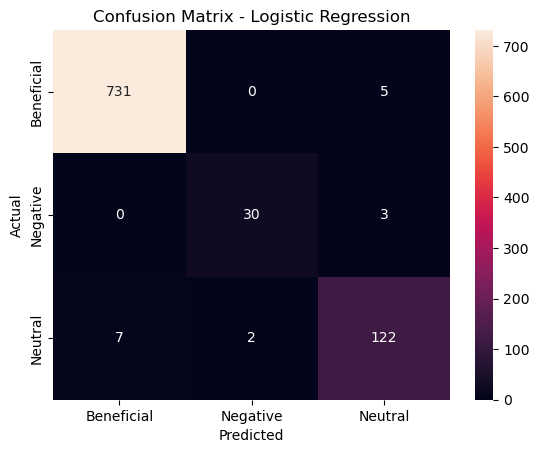

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Saving Results


In [36]:
results = []
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
})

In [37]:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.981111   0.980994  0.981111  0.981041


## KNN Algorithm

In [38]:
from sklearn.neighbors import KNeighborsClassifier

In [39]:
knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

In [40]:
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Daily_Usage_Hours',
                                                   'Weekend_Extra_Hours',
                                                   'Sleep_Duration_Hours',
                                                   'Sleep_Quality_Score',
                                                   'Perceived_Stress_Score',
                                                   'Mental_Health_Index',
                                                   'Academic_Performance_GPA']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Primary_Platform',
                                                   'Device_Type',
                                                   'Social_Comparison_Frequency']),
                                                 ('bool', 'passthrough',
                                                  ['Late_Night_Usage'])])),
                ('model', KNeighborsClassifier())])

In [41]:
y_pred_knn = knn_model.predict(X_test)

In [42]:
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_knn, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_knn, average='weighted'))

Accuracy : 0.9311111111111111
Precision: 0.9284846018179351
Recall   : 0.9311111111111111
F1 Score : 0.9289983616324099


In [43]:
results.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, average='weighted'),
    'Recall': recall_score(y_test, y_pred_knn, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_knn, average='weighted')
})

In [44]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.981111,0.980994,0.981111,0.981041
1,KNN,0.931111,0.928485,0.931111,0.928998


## Decision tree algorithm

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

In [46]:
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [47]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_dt, average='weighted'))

Accuracy : 0.9655555555555555
Precision: 0.9670901372087143
Recall   : 0.9655555555555555
F1 Score : 0.9661375094452613


In [48]:
results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, average='weighted'),
    'Recall': recall_score(y_test, y_pred_dt, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_dt, average='weighted')
})

In [51]:
results_df =pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.981111,0.980994,0.981111,0.981041
1,KNN,0.931111,0.928485,0.931111,0.928998
2,Decision Tree,0.965556,0.967090,0.965556,0.966138


## Random Forest algorithm

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [53]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [54]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_rf, average='weighted'))

Accuracy : 0.9633333333333334
Precision: 0.9626635304659499
Recall   : 0.9633333333333334
F1 Score : 0.9628714144008261


In [55]:
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'Recall': recall_score(y_test, y_pred_rf, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_rf, average='weighted')
})

In [56]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.981111,0.980994,0.981111,0.981041
1,KNN,0.931111,0.928485,0.931111,0.928998
2,Decision Tree,0.965556,0.967090,0.965556,0.966138
3,Random Forest,0.963333,0.962664,0.963333,0.962871


## SVM algorithm

In [61]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC())
])

In [62]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Daily_Usage_Hours',
                                                   'Weekend_Extra_Hours',
                                                   'Sleep_Duration_Hours',
                                                   'Sleep_Quality_Score',
                                                   'Perceived_Stress_Score',
                                                   'Mental_Health_Index',
                                                   'Academic_Performance_GPA']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Primary_Platform',
                                                   'Device_Type',
                                                   'Social_Comparison_Frequency']),
                                                 ('bool', 'passthrough',
                                                  ['Late_Night_Usage'])])),
                ('model', SVC())])

In [63]:
y_pred_svm = svm_model.predict(X_test)

In [64]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_svm, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_svm, average='weighted'))

Accuracy : 0.9722222222222222
Precision: 0.9720259055430385
Recall   : 0.9722222222222222
F1 Score : 0.9720863103484352


In [65]:
results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, average='weighted'),
    'Recall': recall_score(y_test, y_pred_svm, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_svm, average='weighted')
})

In [66]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.981111,0.980994,0.981111,0.981041
1,KNN,0.931111,0.928485,0.931111,0.928998
2,Decision Tree,0.965556,0.967090,0.965556,0.966138
3,Random Forest,0.963333,0.962664,0.963333,0.962871
4,SVM,0.972222,0.972026,0.972222,0.972086


## Gradient boosting method

In [67]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

In [68]:
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Daily_Usage_Hours',
                                                   'Weekend_Extra_Hours',
                                                   'Sleep_Duration_Hours',
                                                   'Sleep_Quality_Score',
                                                   'Perceived_Stress_Score',
                                                   'Mental_Health_Index',
                                                   'Academic_Performance_GPA']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Primary_Platform',
                                                   'Device_Type',
                                                   'Social_Comparison_Frequency']),
                                                 ('bool', 'passthrough',
                                                  ['Late_Night_Usage'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [69]:
y_pred_gb = gb_model.predict(X_test)

In [70]:
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_gb, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_gb, average='weighted'))

Accuracy : 0.9733333333333334
Precision: 0.9735263226185353
Recall   : 0.9733333333333334
F1 Score : 0.9734207379921666


In [71]:
results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb, average='weighted'),
    'Recall': recall_score(y_test, y_pred_gb, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_gb, average='weighted')
})

In [72]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.981111,0.980994,0.981111,0.981041
1,KNN,0.931111,0.928485,0.931111,0.928998
2,Decision Tree,0.965556,0.967090,0.965556,0.966138
3,Random Forest,0.963333,0.962664,0.963333,0.962871
4,SVM,0.972222,0.972026,0.972222,0.972086
5,Gradient Boosting,0.973333,0.973526,0.973333,0.973421


## Comparison of different algorithms

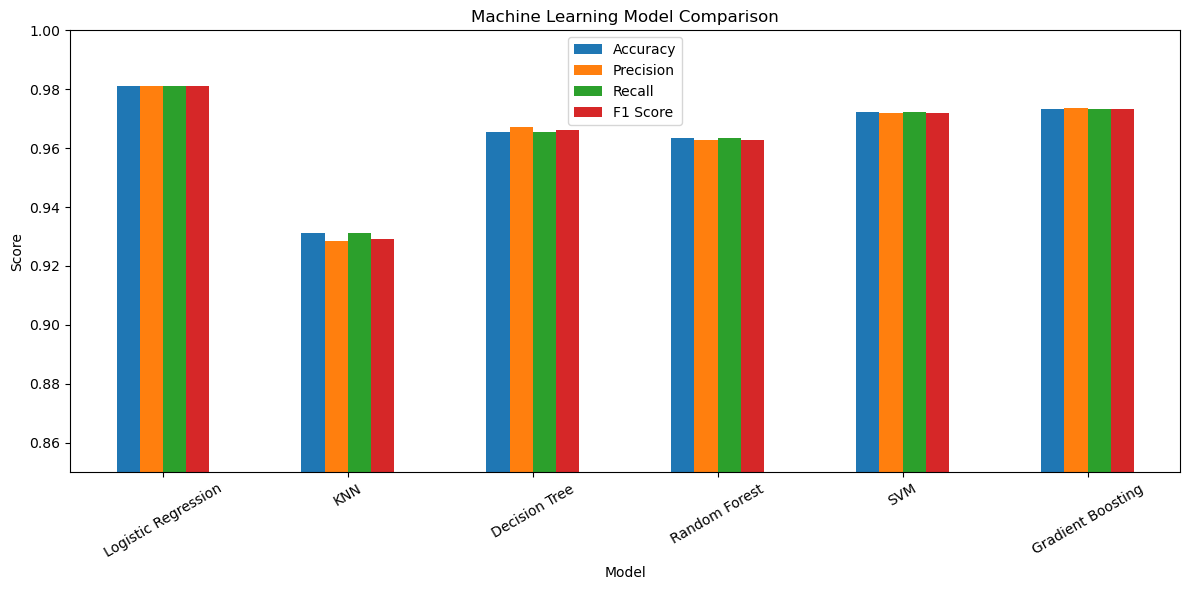

In [73]:
results_plot = results_df.set_index('Model')

results_plot[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.ylabel('Score')
plt.xlabel('Model')
plt.title('Machine Learning Model Comparison')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

Logical Regression Classification report

In [74]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Beneficial       0.99      0.99      0.99       736
    Negative       0.94      0.91      0.92        33
     Neutral       0.94      0.93      0.93       131

    accuracy                           0.98       900
   macro avg       0.96      0.94      0.95       900
weighted avg       0.98      0.98      0.98       900



### 5 fold cross validation of logical regession model